In [2]:
import pandas as pd

In [14]:
# Prompt: I want to see the first few records of the dataset

df = pd.read_csv('dirty_financial_transactions.csv')
df.head()

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status
0,T0001,2024-08-02,C2205,Headphones,-5.0,$420.21,pay pal,NaN
1,T0002,2020-02-10,C3156,Coffee,469.0,-445.34202525395585,creditcard,Pending
2,T0003,2025-02-30,C2919,Tablet,-4.0,810.9930123946459,credit card,completed
3,T0004,2020-08-17,C3009,Tab,-7.0,868.6083413217348,PayPal,Pending
4,T0005,2025-02-30,C3488,Coffee Machine,-10.0,-763.1224490039416,PayPal,completed


In [15]:
# Prompt: Show me descriptive stats on the dataset

df.describe()

,Quantity
count,94981.000000
mean,183.883914
std,299.292365
min,-10.000000
25%,-3.000000
50%,6.000000
75%,327.000000
max,1000.000000


In [16]:
# Prompt: Show me all the columns

print(df.columns)

Index(['Transaction_ID', 'Transaction_Date', 'Customer_ID', 'Product_Name',
       'Quantity', 'Price', 'Payment_Method', 'Transaction_Status'],
      dtype='object')


# Clean payment_method column

In [17]:
# Prompt: How many unique values does column Payment_Method have

print(df['Payment_Method'].unique())

['pay pal' 'creditcard' 'credit card' 'PayPal' 'Cash' 'PayPal '
 'Credit Card']


In [18]:
# Prompt: clean the records of this column

df['Payment_Method'] = df['Payment_Method'].str.strip().str.lower()
df['Payment_Method'] = df['Payment_Method'].replace({
    'creditcard': 'credit card',
    'pay pal': 'paypal'
})
df['Payment_Method'] = df['Payment_Method'].str.title()
print(df['Payment_Method'].unique())

['Paypal' 'Credit Card' 'Cash']


# clean column product_Name

In [19]:
# Prompt: Lets clean column product_Name. First identify the problem

print(df['Product_Name'].value_counts())

Product_Name
Tablet            18444
Laptop            18264
Smartphone        18257
Headphones        18107
Coffee Machine    18085
Lapt                370
Table               352
La                  347
Tabl                346
Lapto               344
Ta                  344
T                   335
Lap                 334
Tab                 330
L                   321
Smartph             234
S                   223
H                   217
He                  212
Smart               206
Head                204
Headpho             203
Smartphon           203
Headphon            203
Smartp              203
Headphone           202
Headp               201
Headph              193
Hea                 192
Sma                 191
Sm                  189
Smartpho            181
Smar                180
Coffee Ma           157
Coffee Machin       150
Coffee Machi        150
Coffee Mach         149
Coffee              149
C                   141
Coffee M            140
Cof                 137
Cof

In [20]:
# Prompt: Use suggestion or Create a mapping that would map dirty values to clean values

product_name_mapping = {
    'Lapt': 'Laptop',
    'Lapto': 'Laptop',
    'La': 'Laptop',
    'Lap': 'Laptop',
    'L': 'Laptop',
    'Tabl': 'Tablet',
    'Table': 'Tablet',
    'Ta': 'Tablet',
    'T': 'Tablet',
    'Tab': 'Tablet',
    'Smartph': 'Smartphone',
    'Smartp': 'Smartphone',
    'Smar': 'Smartphone',
    'Sm': 'Smartphone',
    'Smartpho': 'Smartphone',
    'Smart': 'Smartphone',
    'S': 'Smartphone',
    'Smartphon': 'Smartphone',
    'Sma': 'Smartphone',
    'Headp': 'Headphones',
    'Headph': 'Headphones',
    'Headpho': 'Headphones',
    'Headphon': 'Headphones',
    'Hea': 'Headphones',
    'He': 'Headphones',
    'H': 'Headphones',
    'Head': 'Headphones',
    'Headphone': 'Headphones',
    'Coffee Ma': 'Coffee Machine',
    'Coffee Machi': 'Coffee Machine',
    'Coffee Machin': 'Coffee Machine',
    'Coffee': 'Coffee Machine',
    'Coffee M': 'Coffee Machine',
    'Cof': 'Coffee Machine',
    'Coffe': 'Coffee Machine',
    'Coffee Mac': 'Coffee Machine',
    'Co': 'Coffee Machine',
    'Coff': 'Coffee Machine',
    'C': 'Coffee Machine',
    'Coffee ': 'Coffee Machine',
    'Coffee Mach': 'Coffee Machine'
}

df['Product_Name'] = df['Product_Name'].replace(product_name_mapping)
print("After cleaning:", df['Product_Name'].unique())

After cleaning: ['Headphones' 'Coffee Machine' 'Tablet' 'Smartphone' 'Laptop']


Now, let's clean the `Quantity` column. From the initial summary statistics, we know there are negative values in this column. Assuming these negative values are data entry errors and all quantities should be positive, we will convert them to their absolute values.

In [21]:
# Prompt: now help me fix column quantity

print(f"Minimum Quantity before cleaning: {df['Quantity'].min()}")

Minimum Quantity before cleaning: -10.0


In [22]:
df['Quantity'] = df['Quantity'].abs()

print(f"Minimum Quantity after cleaning: {df['Quantity'].min()}")
print(f"Maximum Quantity after cleaning: {df['Quantity'].max()}")

Minimum Quantity after cleaning: 1.0
Maximum Quantity after cleaning: 1000.0


# Clean price column

Next, let's fix the `Price` column. Similar to `Quantity`, the initial summary statistics indicated the presence of negative values in `Price`. We will convert these negative prices to their absolute values, assuming they are data entry errors.

In [23]:
# Prompt1: Now lets fix column price. Are there any issues with this column
# Prompt2: Fix the missing values
# prompt3: I want to round off by 2 digits this column price.

# Convert 'Price' to numeric, coercing errors to NaN
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Fill NaN values (e.g., with 0 or the mean/median, depending on context)
df['Price'] = df['Price'].fillna(0)

print(f"Minimum Price before cleaning: {df['Price'].min()}")

df['Price'] = df['Price'].abs()

# Round the 'Price' column to two decimal places
df['Price'] = df['Price'].round(2)

print(f"Minimum Price after cleaning: {df['Price'].min()}")
print(f"Maximum Price after cleaning: {df['Price'].max()}")

Minimum Price before cleaning: -999.9689029738316
Minimum Price after cleaning: 0.0
Maximum Price after cleaning: 999.99


# Clean Transaction_Status column

Now, let's clean the `Transaction_Status` column. First, we'll identify the problem by looking at the unique values and their counts.

In [24]:
# prompt: Clean column transaction status
print("Before cleaning:")
print(df['Transaction_Status'].value_counts())

# Convert to lowercase to handle case variations
df['Transaction_Status'] = df['Transaction_Status'].str.lower()

# Standardize 'complete' to 'completed'
df['Transaction_Status'] = df['Transaction_Status'].replace({'complete': 'completed'})

# Capitalize the first letter of each word for consistent formatting
df['Transaction_Status'] = df['Transaction_Status'].str.capitalize()

print("\nAfter cleaning:")
print(df['Transaction_Status'].value_counts())

Before cleaning:
Transaction_Status
Failed       16795
complete     16717
completed    16687
Pending      16595
Completed    16527
Name: count, dtype: int64

After cleaning:
Transaction_Status
Completed    49931
Failed       16795
Pending      16595
Name: count, dtype: int64


Now, let's check for any remaining missing values across all columns.

In [25]:
# Prompt: Find all missing values

print(df.isnull().sum())

Transaction_ID         5018
Transaction_Date       4880
Customer_ID            4878
Product_Name              0
Quantity               5019
Price                     0
Payment_Method            0
Transaction_Status    16679
dtype: int64


In [26]:
# Prompt: Drop rows where 'Transaction_Status' is NaN
df.dropna(subset=['Transaction_Status'], inplace=True)

# Verify missing values after dropping
print("Missing values after dropping rows with missing Transaction_Status:")
print(df['Transaction_Status'].isnull().sum())

Missing values after dropping rows with missing Transaction_Status:
0


In [27]:
print("Missing values in all columns after dropping rows with missing 'Transaction_Status':")
print(df.isnull().sum())

Missing values in all columns after dropping rows with missing 'Transaction_Status':
Transaction_ID        4157
Transaction_Date      4064
Customer_ID           4041
Product_Name             0
Quantity              4200
Price                    0
Payment_Method           0
Transaction_Status       0
dtype: int64


### Handling Missing Values in `Transaction_ID` and `Customer_ID`

Given that `Transaction_ID` and `Customer_ID` are unique identifiers, rows with missing values in these columns often represent incomplete or unidentifiable transactions/customers. It's generally best to drop such rows to maintain data integrity for analysis. I will drop rows where either of these columns has a missing value.

In [28]:
# Prompt: Drop rows where transaction_id and customer_id have missing values
# The quantity column, fill the missing vlaues with median.

# Drop rows where 'Transaction_ID' is NaN
df.dropna(subset=['Transaction_ID'], inplace=True)

# Drop rows where 'Customer_ID' is NaN
df.dropna(subset=['Customer_ID'], inplace=True)

print("Missing values after dropping rows with missing Transaction_ID and Customer_ID:")
print(df.isnull().sum())

Missing values after dropping rows with missing Transaction_ID and Customer_ID:
Transaction_ID           0
Transaction_Date      3694
Customer_ID              0
Product_Name             0
Quantity              3757
Price                    0
Payment_Method           0
Transaction_Status       0
dtype: int64


### Handling Missing Values in `Quantity`

For the `Quantity` column, I will fill the missing values with the *median* of the column. The median is a robust measure that is less affected by outliers compared to the mean, making it a good choice for imputation in numerical columns.

In [29]:
# Prompt: Use suggestion or fill missing values in column Quantity with the median

# Calculate the median of the 'Quantity' column
median_quantity = df['Quantity'].median()

# Fill missing 'Quantity' values with the median
df['Quantity'] = df['Quantity'].fillna(median_quantity)

print(f"Missing values in Quantity after filling with median ({median_quantity}):")
print(df['Quantity'].isnull().sum())

print("\nFinal missing values summary:")
print(df.isnull().sum())

Missing values in Quantity after filling with median (8.0):
0

Final missing values summary:
Transaction_ID           0
Transaction_Date      3694
Customer_ID              0
Product_Name             0
Quantity                 0
Price                    0
Payment_Method           0
Transaction_Status       0
dtype: int64


### Cleaning `Transaction_Date` Column

As requested, I will now attempt to clean the `Transaction_Date` column. This involves converting it to a datetime format. Since we know there are invalid dates (like February 30th), I will use `errors='coerce'` with `pd.to_datetime`. This will convert any unparseable dates into `NaT` (Not a Time), which is pandas' way of representing a missing or invalid datetime value. After this, we can assess how many invalid dates were present and decide on further steps if needed.

In [30]:
# Prompt: Attempt to parse and clean the Transaction_Date column,

# Convert 'Transaction_Date' to datetime, coercing errors to NaT
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'], errors='coerce')

print("Missing values in Transaction_Date after coercing errors:")
print(df['Transaction_Date'].isnull().sum())

print("\nFinal missing values summary after Transaction_Date cleaning:")
print(df.isnull().sum())

Missing values in Transaction_Date after coercing errors:
51375

Final missing values summary after Transaction_Date cleaning:
Transaction_ID            0
Transaction_Date      51375
Customer_ID               0
Product_Name              0
Quantity                  0
Price                     0
Payment_Method            0
Transaction_Status        0
dtype: int64


In [31]:
df['Transaction_Date']

1       2020-02-10
2              NaT
3       2020-08-17
4              NaT
5       2021-10-26
           ...    
99994          NaT
99996   2024-08-25
99997          NaT
99998   2020-07-12
99999   2023-10-04
Name: Transaction_Date, Length: 75320, dtype: datetime64[ns]

### Visualizing Missingness in `Transaction_Date`

To understand the extent of missingness in the `Transaction_Date` column, I'll create a new temporary column called `is_date_missing`. This column will be `True` if the `Transaction_Date` is `NaT` (Not a Time) and `False` otherwise. Then, I will use a count plot to visualize the distribution of these values, clearly showing how many transactions have a valid date versus how many have a missing date.

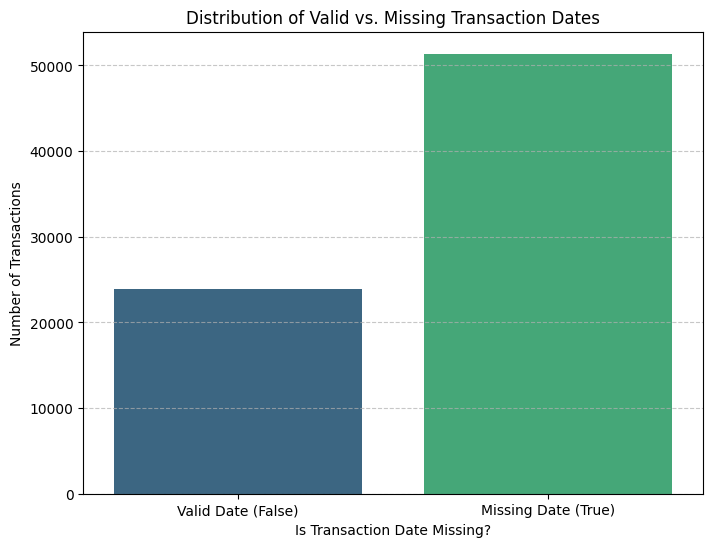

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a boolean column for missing dates
df['is_date_missing'] = df['Transaction_Date'].isnull()

# Visualize the distribution of missing vs. valid dates
plt.figure(figsize=(8, 6))
sns.countplot(x='is_date_missing', data=df, palette='viridis', hue='is_date_missing', legend=False)
plt.title('Distribution of Valid vs. Missing Transaction Dates')
plt.xlabel('Is Transaction Date Missing?')
plt.ylabel('Number of Transactions')
plt.xticks(ticks=[0, 1], labels=['Valid Date (False)', 'Missing Date (True)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Drop the temporary column
df.drop(columns=['is_date_missing'], inplace=True)

### Dropping Rows with Missing `Transaction_Date`

Given the large number of invalid/missing `Transaction_Date` entries, and to ensure we are working with complete transaction records, I will now drop all rows where `Transaction_Date` is `NaT`.

In [33]:
# Prompt: Drop rows where 'Transaction_Date' is NaT
df.dropna(subset=['Transaction_Date'], inplace=True)

print("Missing values after dropping rows with missing Transaction_Date:")
print(df.isnull().sum())

Missing values after dropping rows with missing Transaction_Date:
Transaction_ID        0
Transaction_Date      0
Customer_ID           0
Product_Name          0
Quantity              0
Price                 0
Payment_Method        0
Transaction_Status    0
dtype: int64


In [34]:
df.head()

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status
1,T0002,2020-02-10,C3156,Coffee Machine,469.0,445.34,Credit Card,Pending
3,T0004,2020-08-17,C3009,Tablet,7.0,868.61,Paypal,Pending
5,T0006,2021-10-26,C4241,Smartphone,598.0,0.00,Paypal,Completed
12,T0013,2020-03-18,C1692,Smartphone,564.0,0.00,Cash,Completed
13,T0014,2020-06-19,C2992,Coffee Machine,696.0,905.51,Credit Card,Failed


# Handle duplicates

In [41]:
# Returns the total number of duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

Total duplicate rows: 239


In [42]:
# Returns a Boolean Series where True indicates a duplicate row
duplicates = df.duplicated()

# Display the duplicate records for visual inspection
df[duplicates] = df[df.duplicated()]
df[duplicates]

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status
5455,T5456,2022-11-01,C1548,Tablet,530.0,706.48,Paypal,Pending
5938,T5939,2023-04-14,C2656,Laptop,6.0,0.00,Cash,Completed
8125,T8126,2021-05-25,C2396,Smartphone,4.0,335.99,Paypal,Completed
9123,T7493,2020-03-29,C680,Smartphone,8.0,0.00,Paypal,Completed
15384,T5049,2022-05-23,C1866,Headphones,330.0,442.89,Credit Card,Pending
...,...,...,...,...,...,...,...,...
97961,T97962,2022-09-17,C4247,Laptop,2.0,0.00,Credit Card,Pending
98179,T98180,2020-11-13,C888,Coffee Machine,726.0,466.85,Paypal,Pending
98478,T56209,2022-01-17,C1247,Smartphone,601.0,748.89,Paypal,Failed
98627,T98628,2023-03-31,C2782,Laptop,123.0,0.00,Paypal,Pending


In [43]:
# Keeps the first occurrence, drops subsequent exact clones
df = df.drop_duplicates()

In [44]:
# Returns the total number of duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

Total duplicate rows: 0


# Fix data types

In [45]:
# Option 1: Detailed summary (Recommended)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23706 entries, 1 to 99998
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Transaction_ID      23706 non-null  object        
 1   Transaction_Date    23706 non-null  datetime64[ns]
 2   Customer_ID         23706 non-null  object        
 3   Product_Name        23706 non-null  object        
 4   Quantity            23706 non-null  float64       
 5   Price               23706 non-null  float64       
 6   Payment_Method      23706 non-null  object        
 7   Transaction_Status  23706 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(5)
memory usage: 1.6+ MB


In [47]:
# 1. Reset the index to start from 0 sequentially
df = df.reset_index(drop=True)

# 2. Convert Quantity to integer (use 'Int64' to allow nulls, or 'int64' if zero nulls)
df['Quantity'] = df['Quantity'].astype('int64')

# 3. Optimize memory for text categories
df['Payment_Method'] = df['Payment_Method'].astype('category')
df['Transaction_Status'] = df['Transaction_Status'].astype('category')

# Verify the changes
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23706 entries, 0 to 23705
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Transaction_ID      23706 non-null  object        
 1   Transaction_Date    23706 non-null  datetime64[ns]
 2   Customer_ID         23706 non-null  object        
 3   Product_Name        23706 non-null  object        
 4   Quantity            23706 non-null  int64         
 5   Price               23706 non-null  float64       
 6   Payment_Method      23706 non-null  category      
 7   Transaction_Status  23706 non-null  category      
dtypes: category(2), datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 1.1+ MB
